# Soma + dendrite (linear compartmental) — a non-Markovian, multi-field DAE theory

**Showcases:** the *temporal* side of the framework on a genuinely non-trivial neural model. Three features beyond the plain-Langevin examples appear at once: (i) the **DAE mean-field solver** — both governing relations are *algebraic* (no $\partial_t$), so the saddle is a self-consistent fixed point found by multi-start Newton, not an ODE steady state; (ii) **non-Markovian exponential synaptic kernels** $g(t)=\tfrac1\tau e^{-t/\tau}$ that convolve the inputs (memory in time); and (iii) a **multi-field soma/dendrite** structure whose dendritic spike is a *Bernoulli* event per somatic spike, handled by the framework's CGF machinery $\log\!\big(1+(e^{\tilde n_D}-1)\,p_D\big)$.

$$\lambda^S_i=\Big[E^S_i+\textstyle\sum_j w^{SS}_{ij}\,(g^S_i* n^S_j)+\sum_j w^{SD}_{ij}\,(g^S_i* n^D_j)\Big]_+,\qquad p^D_i=\mathrm{clip}\Big(E^D_i+\textstyle\sum_j w^{DS}_{ij}\,(g^D_i* n^S_j)+\sum_j w^{DD}_{ij}\,(g^D_i* n^D_j),\,0,1\Big).$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — the two populations (size-2 excitatory), the somatic/dendritic spike fields, the four weight matrices, the two exponential kernels, and the self-consistent (algebraic) governing relations.

In [2]:
THEORY = 'single_pop_dendritic_linear'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  Single pop Dendritic Linear
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : nS[E] — Somatic Spike Train; nD[E] — Dendritic Spike Train
Response fields: nSt, nDt
Populations    : E (size 2) — Excitatory
Parameters     :
    wSS [E,E] = [[0.0, 0.0], [0.0, 0.0]]  (real)
    wSD [E,E] = [[0.1, 0.0], [0.0, 0.1]]  (real)
    wDS [E,E] = [[0.1, 0.1], [0.1, 0.1]]  (real)
    wDD [E,E] = [[0.0, 0.0], [0.0, 0.0]]  (real)
    tauS [E] = [1.0, 1.0]  (positive)
    tauD [E] = [1.0, 1.0]  (positive)
    ES [E] = [0.5, 0.5]  (real)
    ED [E] = [0.5, 0.5]  (real)
Mean-field saddle (solved by the pipeline): nSstar, nDstar
Kernel         : gS[E] — non-Markovian temporal convolution
Kernel         : gD[E] — non-Markovian temporal convolution
Governing eqn  : nS[i] = ES[i] + sum(wSS[i,j]*nS[j] + wSD[i,j]*nD[j] for j in E)
Governing eqn  : nD[i] = n

'────────────────────────────────────────────────────────────────────────\n  Single pop Dendritic Linear\n────────────────────────────────────────────────────────────────────────\nDomain         : temporal ODE (time-only)\nFields         : nS[E] — Somatic Spike Train; nD[E] — Dendritic Spike Train\nResponse fields: nSt, nDt\nPopulations    : E (size 2) — Excitatory\nParameters     :\n    wSS [E,E] = [[0.0, 0.0], [0.0, 0.0]]  (real)\n    wSD [E,E] = [[0.1, 0.0], [0.0, 0.1]]  (real)\n    wDS [E,E] = [[0.1, 0.1], [0.1, 0.1]]  (real)\n    wDD [E,E] = [[0.0, 0.0], [0.0, 0.0]]  (real)\n    tauS [E] = [1.0, 1.0]  (positive)\n    tauD [E] = [1.0, 1.0]  (positive)\n    ES [E] = [0.5, 0.5]  (real)\n    ED [E] = [0.5, 0.5]  (real)\nMean-field saddle (solved by the pipeline): nSstar, nDstar\nKernel         : gS[E] — non-Markovian temporal convolution\nKernel         : gD[E] — non-Markovian temporal convolution\nGoverning eqn  : nS[i] = ES[i] + sum(wSS[i,j]*nS[j] + wSD[i,j]*nD[j] for j in E)\nGover

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain. Because both relations are *algebraic*, the mean-field step runs the **DAE solver** (multi-start Newton on the self-consistency, not an ODE integration); it returns the unique low-rate physical saddle $n^S_*,\,n^D_*$. The propagator is built in frequency space from the exponential kernels' Lorentzian factors $1/(1+i\omega\tau)$. We take the connected two-point cumulant $C^{(2)}(\tau)$ between the two neurons' **somatic** spike trains (`('nS',1)` × `('nS',2)`) at tree level. The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=0,                          # two-point ⟨nS nS⟩, tree level
    external_fields=[('nS', 1), ('nS', 2)],  # somatic spikes, neuron 1 × neuron 2
    tau_grid=(-20.0, 20.0, 81),              # C(τ) on τ ∈ [0, 20]
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)
# parameters: the model's own parameter defaults are used (weights, τ's,
# resting drives baked into the theory file).  Pin them here for clarity
# and to guarantee the theory and the simulator share identical numbers.
fundamental = {
    'wSS': [[0.0, 0.0], [0.0, 0.0]],   'wSD': [[0.1, 0.0], [0.0, 0.1]],
    'wDS': [[0.1, 0.1], [0.1, 0.1]],   'wDD': [[0.0, 0.0], [0.0, 0.0]],
    'tauS': [1.0, 1.0], 'tauD': [1.0, 1.0],
    'ES':   [0.5, 0.5], 'ED':   [0.5, 0.5],
}
cfg.parameters = fundamental


theory : 'Single pop Dendritic Linear'
k      : 2    max_ell : 0
fields : ['dnS', 'dnD']   spatial_dim : 0
mean-field saddle: nS* = [0.53228, 0.53228],  nD* = [0.3228, 0.3228]


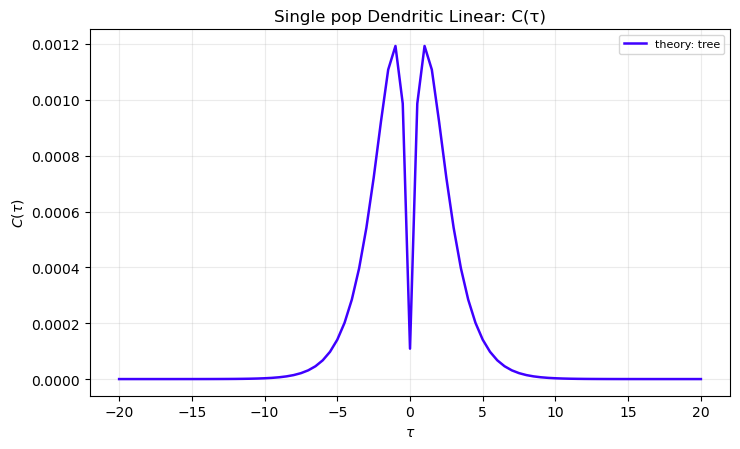

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
print('mean-field saddle: nS* = %s,  nD* = %s'
      % (np.round(res['mf_values']['nSstar'], 5).tolist(),
         np.round(res['mf_values']['nDstar'], 5).tolist()))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct event-driven Monte-Carlo of the spiking network — written from scratch (numba), with no reference to the diagrammatics. Each soma fires as an inhomogeneous Poisson process with the rectified-linear rate above; each dendrite fires per somatic spike with the clipped-linear Bernoulli probability $p_D$. The synaptic drive is the running exponential filter of past spikes. We estimate the *connected* $C^{(2)}(\tau)$ slice between the two somatic trains (the estimator returns the connected cumulant directly — no mean subtraction needed) and overlay it on the pipeline curve.

sim: 6 runs × 1.5e+08 steps in 44.1s   somatic rate ≈ [0.5325, 0.5328] (MF: [0.5323, 0.5323])
theory C(0) = 0.00011    sim C(0) = 0.00068 ± 0.00016
cross-correlation peak  τ ≈ -1.0:  theory = 0.00119   sim = 0.00135 ± 0.00019


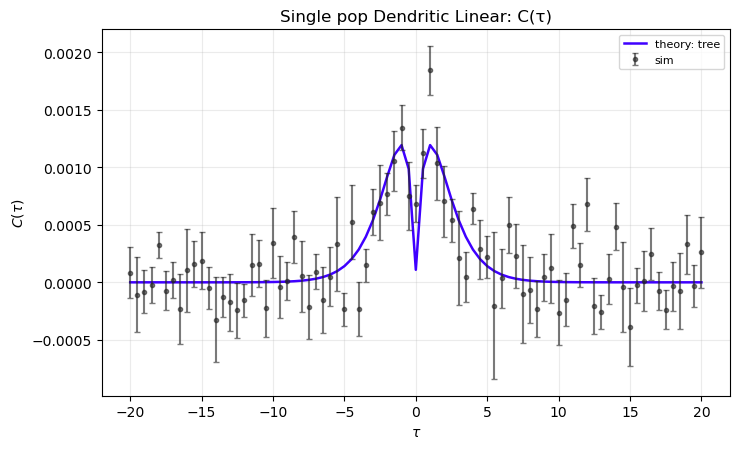

In [5]:
from models.dendritic_linear_sim_numba import (
    sim_dendritic_linear_numba, build_sim_arrays, flat_index_of,
    stack_binned_counts)
from models.cumulant_estimator import estimate_kpoint_slices

# Reduced Monte-Carlo budget for a fast showcase (~1 min); the off-diagonal
# cross-correlation is a small signal, so we run several independent seeds
# to pin the statistical band.  This numba kernel is SERIAL (no fork) — safe.
# (Native int()/float() casts: the Sage kernel preparses bare literals to
#  Sage types, which numba's nopython compiler cannot type — so cast.)
T_sim, dt_sim, dt_bin, N_RUNS = 1_500_000.0, 0.01, 0.5, 6
tau_max = float(np.max(np.abs(res['tau_grid'])))

# Translate model + saddle into the per-array sim inputs.
arr = build_sim_arrays(model, fundamental, res['mf_values'])
N   = arr['N']
wSS, wSD, wDS, wDD = arr['wSS'], arr['wSD'], arr['wDS'], arr['wDD']
tauS, tauD, ES, ED = arr['tauS'], arr['tauD'], arr['ES'], arr['ED']
stack_offsets      = arr['stack_offsets']

# Discretization + τ grid (the sim's own binned grid).
n_steps    = int(T_sim / dt_sim)
bin_steps  = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff = float(bin_steps * dt_sim)
n_bins     = int(n_steps // bin_steps)
max_lag_bins = int(tau_max / dt_bin_eff)
tau_sim    = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

# The k external legs → flat sim rows (leg 0 = the lag-0 anchor; legs 1..k−1
# are swept one at a time by the estimator).  pop_indices / field_types have
# length k, exactly as estimate_kpoint_slices expects.
ext         = cfg.external_fields
pop_indices = [flat_index_of(stack_offsets, e[0], e[1]) for e in ext]
field_types = [e[0] for e in ext]
CAP_PD_AT_ONE = True   # paper convention: dendritic prob clipped at 1

# k−1 cumulant slices, matching the theory's res['C_tau_slices'] and the
# k≥3 panels of dd.plot_cumulant.  The base point for the non-swept legs is
# cfg.kpoint_base_lags (default all-0 → the slices pass through the origin).
k    = int(res['_resolved']['k'])
base = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0] * (k - 1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]

# JIT warm-up (first numba call compiles), then N_RUNS independent seeds.
_ = sim_dendritic_linear_numba(int(1000), float(dt_sim), wSS, wSD, wDS, wDD,
                               tauS, tauD, ES, ED, int(bin_steps), int(100),
                               int(0), CAP_PD_AT_ONE)
t0 = time.perf_counter()
C_runs, rate_S = [], []
for run in range(N_RUNS):
    nS_b, nD_b, _lam, _pD, totS, totD = sim_dendritic_linear_numba(
        int(n_steps), float(dt_sim), wSS, wSD, wDS, wDD, tauS, tauD, ES, ED,
        int(bin_steps), int(n_bins), int(11 + run), CAP_PD_AT_ONE)
    rate_S.append([float(totS[i]) / T_sim for i in range(N)])
    # Dendritic legs are spike trains (field_types like 'dn'/'nS') → the
    # stacked spike-count array is the relevant data (no voltage channel).
    binned_stacked = stack_binned_counts(nS_b, nD_b)
    tau_sim, Cj = estimate_kpoint_slices(
        float(dt_bin_eff), [int(p) for p in pop_indices], field_types,
        base_bins, int(max_lag_bins), binned_counts=binned_stacked)
    C_runs.append(np.asarray(Cj))             # (k-1, n_tau)
C_arr = np.array(C_runs).real
C_sim = C_arr.mean(axis=0); C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}   # 2-D: one row per slice
print('sim: %d runs × %g steps in %.1fs   somatic rate ≈ %s (MF: %s)'
      % (N_RUNS, n_steps, time.perf_counter() - t0,
         np.round(np.mean(rate_S, axis=0), 4).tolist(),
         np.round(arr['nS_mf'], 4).tolist()))

# At k=2 there is a single slice (row 0); report C(0) and the cross-corr peak.
tg, Cth = res['tau_grid'], np.real(res['C_tau'])
ipk = np.argmax(Cth)
print('theory C(0) = %.5f    sim C(0) = %.5f ± %.5f'
      % (Cth[np.argmin(np.abs(tg))],
         C_sim[0][max_lag_bins], C_err[0][max_lag_bins]))
print('cross-correlation peak  τ ≈ %.1f:  theory = %.5f   sim = %.5f ± %.5f'
      % (tg[ipk], Cth[ipk],
         np.interp(tg[ipk], tau_sim, C_sim[0]),
         np.interp(tg[ipk], tau_sim, C_err[0])))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

A two-compartment (soma + dendrite) linear compartmental network, run through the full MSR-JD pipeline at tree level. Three pieces of machinery carried the calculation: the **DAE mean-field solver** (the saddle is a self-consistent fixed point of two *algebraic* relations), the **non-Markovian exponential synaptic kernels** (Lorentzian propagator factors $1/(1+i\omega\tau)$), and the **multi-field Bernoulli CGF** for the dendritic-spike channel.

The somatic cross-correlation $C^{(2)}_{12}(\tau)$ is a **delayed bump** — near zero at $\tau=0$ (two different neurons are uncorrelated at equal time) and peaking at $\tau\!\approx\!1$–$2$, the lag set by the synaptic filter time constant as the two somata talk through their shared dendritic pathway. The event-driven simulation reproduces this delayed shape within statistics.

**Caveat (physics).** The off-diagonal cross-correlation is a *small* signal (peak $\sim10^{-3}$), so the honest comparison is the **curve / peak**, not the single point $C(0)$: $\tau=0$ sits at a near-node of the cross-correlation, where the finite-bin Poisson self-variance and the Monte-Carlo floor dominate the genuinely-tiny equal-time value. A second, known mismatch source is the simulator's $p_D$ **cap at 1** (paper convention), which the MSR-JD Bernoulli action does not impose — negligible here at low drive, but it grows if `ED` or the weights push $p_D$ toward the boundary.